TASK 1 (Advanced Text Preprocessing)

🎯 Goal:

Clean review text

Remove noise

Apply:

POS filtering

Lemmatization

Domain cleaning

In [16]:
import nltk
import spacy

nlp = spacy.load("en_core_web_sm")

print("All working ✅")

All working ✅


IMPORT AND LOAD DATA

In [17]:
import pandas as pd

from pathlib import Path

_cwd = Path.cwd()
_project_root = _cwd.parent if _cwd.name.lower() == "notebooks" else _cwd
df = pd.read_csv(_project_root / "data" / "feature_engineered.csv")

# Use review text column
text_col = "Review Text"

df = df.dropna(subset=[text_col])

Basic Cleaning

In [18]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", "", text)   # remove special chars
    text = re.sub(r"\s+", " ", text)
    return text

df["clean_text"] = df[text_col].apply(clean_text)

NLP Processing (SPACY)

In [19]:
import spacy

nlp = spacy.load("en_core_web_sm")

def advanced_preprocess(texts):
    processed_texts = []
    # Using nlp.pipe is much faster for batch processing
    for doc in nlp.pipe(texts, batch_size=1000, disable=["ner", "parser"]):
        tokens = []
        for token in doc:
            # Remove stopwords + punctuation
            if token.is_stop or token.is_punct:
                continue
            
            # Keep only useful POS
            if token.pos_ in ["NOUN", "ADJ", "VERB"]:
                tokens.append(token.lemma_)
        
        processed_texts.append(" ".join(tokens))
    
    return processed_texts

Apply Preprocessing

In [20]:
df["processed_text"] = advanced_preprocess(df["clean_text"].astype(str).tolist())

print(df[["clean_text", "processed_text"]].head())

Task 2: Generate word clouds for positive and negative reviews by weighting words based on TF-IDF scores instead of simple frequency counts, removing neutral terms dynamically, and enhancing visualization with bigram and trigram analysis.

In [ ]:
import pandas as pd

# Load dataset
from pathlib import Path

_cwd = Path.cwd()
_project_root = _cwd.parent if _cwd.name.lower() == "notebooks" else _cwd
df = pd.read_csv(_project_root / "data" / "feature_engineered.csv")

# Check
print("Data Loaded ✅")
print(df.shape)
print(df.columns)

Data Loaded ✅
(23486, 80)
Index(['Unnamed: 0', 'Clothing ID', 'Age', 'Review Text', 'Rating',
       'Recommended IND', 'Positive Feedback Count', 'engagement_scaled',
       'engagement_cluster', 'Division Name_General',
       'Division Name_General Petite', 'Division Name_Initmates',
       'Department Name_Bottoms', 'Department Name_Dresses',
       'Department Name_Intimate', 'Department Name_Jackets',
       'Department Name_Tops', 'Department Name_Trend',
       'sentiment_category_neutral', 'sentiment_category_positive',
       'engagement_level_Low', 'engagement_level_Medium', 'clean_text',
       'membership_days', 'membership_normalized', 'lifecycle_stage', 'PCA_0',
       'PCA_1', 'PCA_2', 'PCA_3', 'PCA_4', 'PCA_5', 'PCA_6', 'PCA_7', 'PCA_8',
       'PCA_9', 'PCA_10', 'PCA_11', 'PCA_12', 'PCA_13', 'PCA_14', 'PCA_15',
       'PCA_16', 'PCA_17', 'PCA_18', 'PCA_19', 'PCA_20', 'PCA_21', 'PCA_22',
       'PCA_23', 'PCA_24', 'PCA_25', 'PCA_26', 'PCA_27', 'PCA_28', 'PCA_29',
     

In [23]:
positive_df = df[df["Rating"] >= 4]
negative_df = df[df["Rating"] <= 2]

pos_text = positive_df["Review Text"]
neg_text = negative_df["Review Text"]

print("Positive:", len(pos_text))
print("Negative:", len(neg_text))

Positive: 18208
Negative: 2407


In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=1000,
    ngram_range=(1,3),   #  unigram + bigram + trigram
    stop_words="english"
)

# Positive TF-IDF
pos_tfidf = vectorizer.fit_transform(pos_text)
pos_words = vectorizer.get_feature_names_out()
pos_scores = pos_tfidf.sum(axis=0).A1

pos_dict = dict(zip(pos_words, pos_scores))

In [25]:
vectorizer_neg = TfidfVectorizer(
    max_features=1000,
    ngram_range=(1,3),
    stop_words="english"
)

neg_tfidf = vectorizer_neg.fit_transform(neg_text)
neg_words = vectorizer_neg.get_feature_names_out()
neg_scores = neg_tfidf.sum(axis=0).A1

neg_dict = dict(zip(neg_words, neg_scores))

In [26]:
common_words = set(pos_dict.keys()).intersection(set(neg_dict.keys()))

for word in common_words:
    pos_dict.pop(word, None)
    neg_dict.pop(word, None)

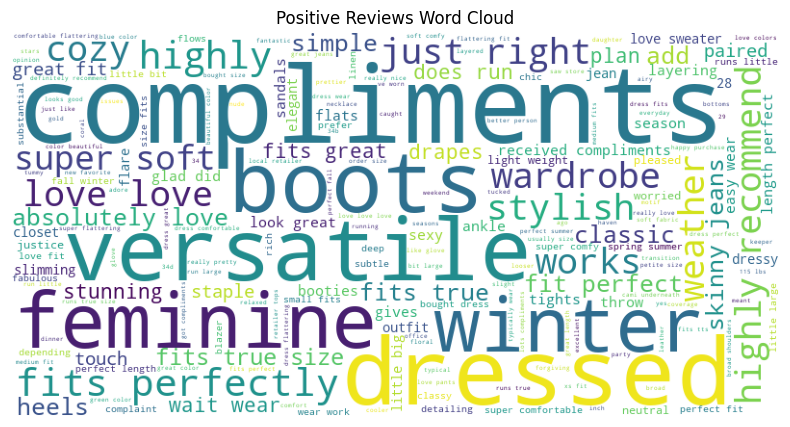

In [27]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wc_pos = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate_from_frequencies(pos_dict)

plt.figure(figsize=(10,5))
plt.imshow(wc_pos)
plt.axis("off")
plt.title("Positive Reviews Word Cloud")
plt.show()

Task 3: Build a sentiment analysis model using a pre-trained transformer by fine-tuning models like BERT, RoBERTa, or DistilBERT on domain-specific data, incorporating transfer learning, and optimizing inference efficiency for real-time applications.

In [5]:
import pandas as pd

df = pd.read_csv("../data/feature_engineered.csv")

df = df.dropna(subset=["Review Text"])

# Binary sentiment
df["label"] = df["Rating"].apply(lambda x: 1 if x >= 4 else 0)

# Reduce size (IMPORTANT for speed)
df = df.sample(5000, random_state=42)

texts = df["Review Text"].tolist()
labels = df["label"].tolist()

In [6]:
from sklearn.model_selection import train_test_split

train_texts, val_texts, train_labels, val_labels = train_test_split(
    texts, labels, test_size=0.2, random_state=42
)

In [7]:
from transformers import DistilBertTokenizer

tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")

train_encodings = tokenizer(train_texts, truncation=True, padding=True)
val_encodings = tokenizer(val_texts, truncation=True, padding=True)

In [8]:
import torch

class ReviewDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = ReviewDataset(train_encodings, train_labels)
val_dataset = ReviewDataset(val_encodings, val_labels)

In [9]:
from transformers import DistilBertForSequenceClassification

model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 552.31it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [10]:
import torch

class ReviewDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = ReviewDataset(train_encodings, train_labels)
val_dataset = ReviewDataset(val_encodings, val_labels)

In [12]:
from transformers import DistilBertForSequenceClassification

model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 2851.43it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [5]:
pip install --upgrade transformers

  Using cached transformers-5.5.0-py3-none-any.whl.metadata (32 kB)
Using cached transformers-5.5.0-py3-none-any.whl (10.2 MB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import transformers
print(transformers.__version__)

c:\Users\smitd\OneDrive\Desktop\brainy_beam\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


5.5.0


Task 4: Identify the most common words in positive vs. negative reviews by analyzing co-occurrence patterns, performing sentiment-specific n-gram extraction, and leveraging contextual embeddings like Word2Vec or GloVe for deeper semantic insights.

In [18]:
import sys
!{sys.executable} -m pip install gensim

   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
   ---------------------------------------- 0.3/24.4 MB ? eta -:--:--
   -- ------------------------------------- 1.3/24.4 MB 5.3 MB/s eta 0:00:05
   ---- ----------------------------------- 2.6/24.4 MB 5.8 MB/s eta 0:00:04
   ------ --------------------------------- 3.9/24.4 MB 5.8 MB/s eta 0:00:04
   -------- ------------------------------- 5.0/24.4 MB 5.9 MB/s eta 0:00:04
   ---------- ----------------------------- 6.3/24.4 MB 6.0 MB/s eta 0:00:04
   ------------ --------------------------- 7.3/24.4 MB 5.8 MB/s eta 0:00:03
   -------------- ------------------------- 8.9/24.4 MB 6.0 MB/s eta 0:00:03
   ----------------- ---------------------- 10.5/24.4 MB 6.1 MB/s eta 0:00:03
   ------------------- -------------------- 11.8/24.4 MB 6.2 MB/s eta 0:00:03
   --------------------- ------------------ 13.1/24.4 MB 6.2 MB/s eta 0:00:02
   ----------------------- ---------------- 14.4/24.4 MB 6.2 MB/s eta 0:00:02
   ------

In [ ]:
# =========================================
# NLP TASK 4: CO-OCCURRENCE + WORD2VEC
# =========================================

import pandas as pd
import re
from collections import Counter
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer
from gensim.models import Word2Vec

# -----------------------------
# STEP 1: LOAD DATA
# -----------------------------
df = pd.read_csv("../data/feature_engineered.csv")
df = df.dropna(subset=["Review Text"])

# -----------------------------
# STEP 2: BASIC CLEANING
# -----------------------------
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", "", text)
    return text

df["clean_text"] = df["Review Text"].apply(clean_text)

# -----------------------------
# STEP 3: SPLIT POSITIVE / NEGATIVE
# -----------------------------
pos_df = df[df["Rating"] >= 4]
neg_df = df[df["Rating"] <= 2]

pos_text = pos_df["clean_text"]
neg_text = neg_df["clean_text"]

# -----------------------------
# STEP 4: MOST COMMON WORDS
# -----------------------------
def get_top_words(text_series, n=20):
    words = " ".join(text_series).split()
    return Counter(words).most_common(n)

print("Top Positive Words:", get_top_words(pos_text))
print("\nTop Negative Words:", get_top_words(neg_text))

# -----------------------------
# STEP 5: N-GRAM EXTRACTION
# -----------------------------
vectorizer = CountVectorizer(ngram_range=(2,3), max_features=20)

# Positive n-grams
pos_ngrams = vectorizer.fit_transform(pos_text)
pos_ngram_freq = zip(vectorizer.get_feature_names_out(), pos_ngrams.sum(axis=0).A1)

print("\nTop Positive N-grams:")
print(sorted(pos_ngram_freq, key=lambda x: x[1], reverse=True)[:10])

# Negative n-grams
neg_ngrams = vectorizer.fit_transform(neg_text)
neg_ngram_freq = zip(vectorizer.get_feature_names_out(), neg_ngrams.sum(axis=0).A1)

print("\nTop Negative N-grams:")
print(sorted(neg_ngram_freq, key=lambda x: x[1], reverse=True)[:10])

# -----------------------------
# STEP 6: CO-OCCURRENCE (WORD PAIRS)
# -----------------------------
def get_cooccurrence(text_series, n=10):
    pairs = []
    for text in text_series:
        words = text.split()
        for i in range(len(words)-1):
            pairs.append((words[i], words[i+1]))
    return Counter(pairs).most_common(n)

print("\nTop Positive Co-occurrence:", get_cooccurrence(pos_text))
print("\nTop Negative Co-occurrence:", get_cooccurrence(neg_text))

# -----------------------------
# STEP 7: WORD2VEC (SEMANTIC)
# -----------------------------
# Prepare tokenized sentences
sentences = [text.split() for text in df["clean_text"]]

# Train model
w2v_model = Word2Vec(
    sentences,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4
)

# -----------------------------
# STEP 8: WORD SIMILARITY
# -----------------------------
print("\nWords similar to 'dress':")
print(w2v_model.wv.most_similar("dress", topn=5))

print("\nWords similar to 'bad':")
print(w2v_model.wv.most_similar("bad", topn=5))


Top Positive Words: [('the', 55494), ('i', 45111), ('and', 38378), ('a', 33900), ('it', 31933), ('is', 24222), ('this', 19612), ('to', 18588), ('in', 15773), ('but', 11832), ('on', 11058), ('for', 10845), ('with', 10832), ('of', 9793), ('so', 9262), ('my', 8589), ('dress', 7950), ('love', 7713), ('that', 7291), ('was', 7229)]

Top Negative Words: [('the', 9133), ('i', 6025), ('it', 4740), ('and', 4677), ('a', 3803), ('this', 2838), ('is', 2776), ('to', 2574), ('was', 2379), ('in', 2140), ('but', 1886), ('on', 1806), ('of', 1641), ('not', 1439), ('so', 1240), ('for', 1224), ('dress', 1117), ('like', 1048), ('that', 976), ('my', 972)]

Top Positive N-grams:
[('in the', np.int64(5200)), ('it is', np.int64(4972)), ('and the', np.int64(4289)), ('this dress', np.int64(3579)), ('on the', np.int64(3132)), ('of the', np.int64(2668)), ('and it', np.int64(2468)), ('this is', np.int64(2229)), ('this top', np.int64(2209)), ('love the', np.int64(2197))]

Top Negative N-grams:
[('in the', np.int64(90

In [3]:
import os
from pathlib import Path

_cwd = Path.cwd()
BASE_DIR = str(_cwd.parent if _cwd.name.lower() == "notebooks" else _cwd)

rf_path = os.path.join(BASE_DIR, "model", "random_forest.pkl")
lr_path = os.path.join(BASE_DIR, "model", "logistic_model.pkl")
